In [1]:
# =================================================================
# Author:           Achraf Bourekba
# LinkedIn:         Achraf B.
# Python Version:   3.11.9
#
# Required Libraries:
#   - OpenCV (cv2)
#   - Matplotlib
#   - Ultralytics (YOLO)
# =================================================================

Importing Necessary libraries 

In [2]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

In [3]:
image = cv2.imread("image2.jpg")
print("Image type", type(image))
cv2.imshow("Image name", image)
cv2.waitKey(0) 

Image type <class 'numpy.ndarray'>


-1

Plotting Image

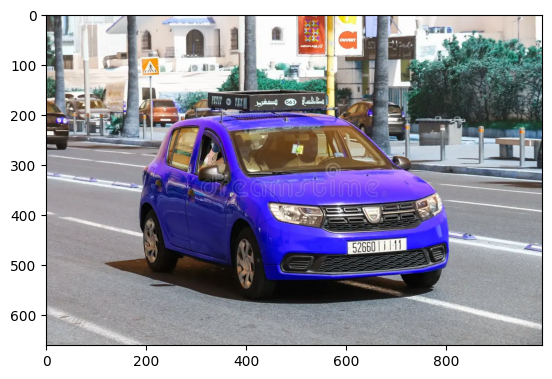

In [4]:
plt.imshow(image)

Converting image color from RGB to BGR 

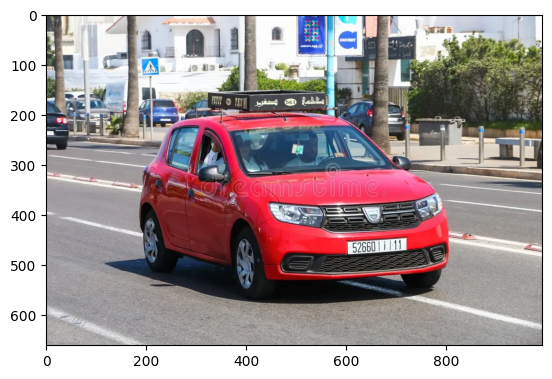

In [5]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)

Image GrayScaling 


image shape (661, 992)


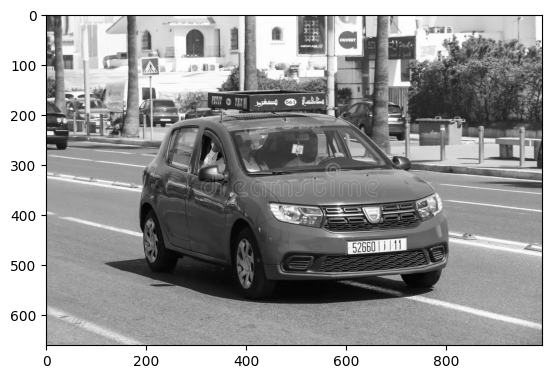

In [6]:
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
print("image shape", image_gray.shape)
plt.imshow(image_gray, cmap="gray")


Image Resize

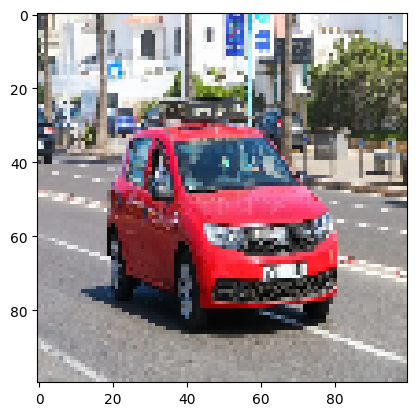

In [7]:
small_image = cv2.resize(image_rgb, (100, 100))
plt.imshow(small_image)

Plotting Original RGB Image Alongside a Blurred Version

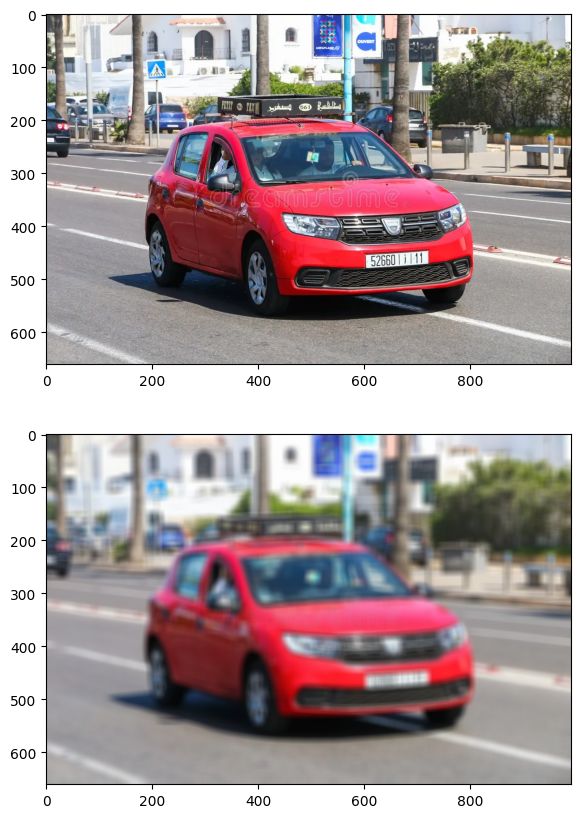

In [8]:
ksize = (15, 15)
  
image_blured = cv2.blur(image_rgb, ksize) 

fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (15, 10))
ax1.imshow(image_rgb)
  
ax2.imshow(image_blured)

Canny Edge Detection

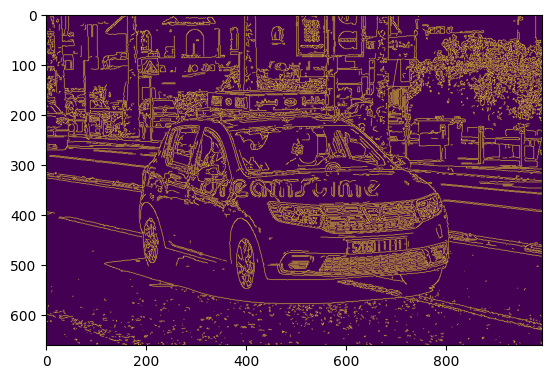

In [9]:
image_edge = cv2.Canny(image_rgb, 125, 175) 
plt.imshow(image_edge)

Rectangle Methode 1 

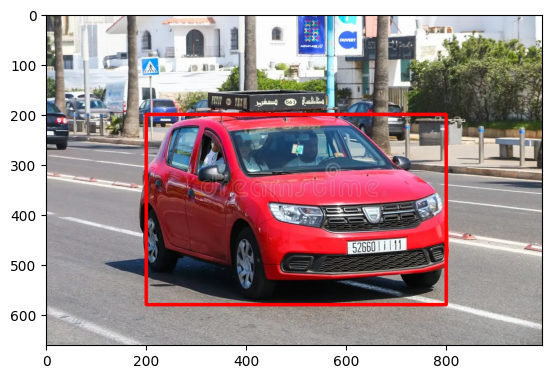

In [10]:
start_point = (200, 200) 
  
end_point = (800, 580)
  
color = (255, 0, 0)
  
thickness = 5
  
image_rectangle = cv2.rectangle(image_rgb, start_point, end_point, color, thickness)
  
plt.imshow(image_rectangle)

Bound Images With YOLOv8n



0: 448x640 5 cars, 142.0ms
Speed: 4.0ms preprocess, 142.0ms inference, 8.6ms postprocess per image at shape (1, 3, 448, 640)


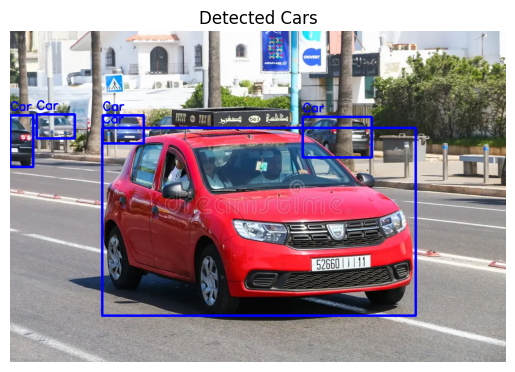

In [11]:
model = YOLO("yolov8n.pt")


if image is None:
    print("Error: Image not found")
    exit()

results = model(image)

for r in results:
    for box in r.boxes:
        cls = int(box.cls[0])
        label = model.names[cls]
        
        if label == "car":
            x1, y1, x2, y2 = map(int, box.xyxy[0])

            cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 3)

            cv2.putText(image, "Car", (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Show result
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Detected Cars")
plt.show()